# exp005 - audio temporal localisation

this is the corrected audio run after the first attempt decoded the audio badly and ended up with zero-valued features.

main thing to remember: this is **not** generic fake/real classification. the target is whether each sampled **audio window** is manipulated.

```text
real                         -> audio labels all 0
fake_video_real_audio        -> audio labels all 0
real_video_fake_audio        -> labels from audio_fake_segments
fake_video_fake_audio        -> labels from audio_fake_segments
```

the video-only fake condition is the useful shortcut check because its audio should still be real.

## feature design

audio pipeline used here:

```text
mp4 audio
-> ffmpeg stream extraction
-> 16 khz mono pcm
-> 64 sampled temporal windows
-> 0.96 s waveform around each centre
-> log-stft
-> mean + std for each of 201 frequency bins
-> 402 features per window
```

this is deliberately a lightweight audio baseline rather than a pretrained speech model.

In [1]:
# imports + reproducibility

from pathlib import Path
from datetime import datetime
import json
import shutil
import zipfile
import hashlib
import ast
import random
import time
import gc
import subprocess

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import FileLink, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_float32_matmul_precision("high")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
# longer helpers are split by purpose for this experiment
from utils.data_utils import (
    find_existing_split_source,
    add_modality_labels,
    load_metadata_json_if_available,
    enrich_with_metadata_if_needed,
    audit_audio_segments,
    filter_audio_temporal_rows,
    group_overlap_summary,
)

from utils.audio_utils import (
    probe_audio_stream,
    decode_audio_ffmpeg,
    run_audio_decode_preflight,
    make_audio_feature_loader,
    extract_audio_feature_shards,
)

from utils.temporal_utils import (
    get_shard_paths,
    compute_window_label_counts,
    AudioTemporalLinearHead,
    iter_audio_temporal_minibatches,
    safe_auc,
    evaluate_audio_temporal_model,
    plot_audio_temporal_examples,
)


Torch: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA A40


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# paths used on the qmul jupyter environment

PROJECT_ROOT = Path("/home/jovyan/MSC_PROJECT")
DATA_DIR = PROJECT_ROOT / "data" / "avdeepfake1mpp"
MANIFEST_DIR = DATA_DIR / "manifests"
EXPORTS_DIR = PROJECT_ROOT / "exports"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_FILENAME = "exp005_audio_temporal_bal40k.ipynb"
NOTEBOOK_PATH = PROJECT_ROOT / NOTEBOOK_FILENAME

PATH_COL = "path"
RELATIVE_PATH_COL = "relative_path"
CONDITION_COL = "condition"

AUDIO_SEGMENT_COL = "audio_fake_segments"
VISUAL_SEGMENT_COL = "visual_fake_segments"

# keep generic fake_segments fallback off - it may describe a non-audio manipulation
USE_FALLBACK_FAKE_SEGMENTS = False
FALLBACK_SEGMENT_COLS = ["fake_segments"] if USE_FALLBACK_FAKE_SEGMENTS else []

METADATA_JSON_CANDIDATES = [
    DATA_DIR / "val_metadata.json",
    PROJECT_ROOT / "val_metadata.json",
    Path("/mnt/data/val_metadata.json"),
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("EXPECTED NOTEBOOK_PATH:", NOTEBOOK_PATH)
print("Notebook exists at expected path:", NOTEBOOK_PATH.exists())

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT not found: {PROJECT_ROOT}")

PROJECT_ROOT: /home/jovyan/MSC_PROJECT
DATA_DIR: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp
EXPECTED NOTEBOOK_PATH: /home/jovyan/MSC_PROJECT/exp005_audio_temporal_bal40k.ipynb
Notebook exists at expected path: True


## experiment config

In [3]:
# main exp005 settings

EXPERIMENT_ID = "exp005"
EXPERIMENT_NAME = "audio_temporal_bal40k"
RUN_NAME = f"{EXPERIMENT_ID}_{EXPERIMENT_NAME}"

# reuse the earlier balanced group-disjoint split
SPLIT_SOURCE_CANDIDATES = [
    "exp002_visual_clip_bal40k",
    "002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames",
    "002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k",
]

AUDIO_SAMPLE_RATE = 16000
NUM_AUDIO_WINDOWS = 64

# 64 centres spread across the decoded clip
AUDIO_WINDOW_SECONDS = 0.96

# STFT feature settings.
N_FFT = 400              # 25 ms at 16 kHz
HOP_LENGTH = 160         # 10 ms at 16 kHz
WIN_LENGTH = 400

# 201 stft bins x (mean + std) = 402 features
AUDIO_FEATURE_DIM = 2 * (N_FFT // 2 + 1)

FEATURE_BATCH_SIZE = 32
NUM_WORKERS = 2
PREFETCH_FACTOR = 1
PIN_MEMORY = False

TEMPORAL_BATCH_SIZE = 64
TEMPORAL_EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DEFAULT_THRESHOLD = 0.5

# audio-fake rows without usable temporal labels are dropped
MISSING_AUDIO_SEGMENT_POLICY = "drop"

# audio-real metadata conflicts stay negative but are logged
KEEP_AUDIO_REAL_CONFLICTS_AS_NEGATIVE = True

POS_WEIGHT_CAP = 20.0

EXPERIMENT_CONFIG = {
    "run_name": RUN_NAME,
    "task": "audio_temporal_localisation_balanced40k",
    "model": "ffmpeg pcm_s16le stream-copy audio extraction + Log-STFT temporal features + per-window linear head",
    "dataset": "AV-Deepfake1M++ validation subset",
    "split_source_candidates": SPLIT_SOURCE_CANDIDATES,
    "split_policy": "reuse balanced group-disjoint Experiment 002 split",
    "target": "window-level audio_fake labels from condition + audio_fake_segments",
    "audio_segment_col": AUDIO_SEGMENT_COL,
    "use_fallback_fake_segments": USE_FALLBACK_FAKE_SEGMENTS,
    "sample_rate": AUDIO_SAMPLE_RATE,
    "num_audio_windows": NUM_AUDIO_WINDOWS,
    "audio_window_seconds": AUDIO_WINDOW_SECONDS,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "win_length": WIN_LENGTH,
    "audio_feature_dim": AUDIO_FEATURE_DIM,
    "decode_format": "pcm_s16le stream-copy first, decode fallback",
    "preflight_decode_required": True,
    "feature_batch_size": FEATURE_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "prefetch_factor": PREFETCH_FACTOR,
    "pin_memory": PIN_MEMORY,
    "temporal_batch_size": TEMPORAL_BATCH_SIZE,
    "temporal_epochs": TEMPORAL_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "default_threshold": DEFAULT_THRESHOLD,
    "missing_audio_segment_policy": MISSING_AUDIO_SEGMENT_POLICY,
    "keep_audio_real_conflicts_as_negative": KEEP_AUDIO_REAL_CONFLICTS_AS_NEGATIVE,
    "pos_weight_cap": POS_WEIGHT_CAP,
    "seed": SEED,
}

EXPERIMENT_CONFIG

{'run_name': 'exp005_audio_temporal_bal40k',
 'task': 'audio_temporal_localisation_balanced40k',
 'model': 'ffmpeg pcm_s16le stream-copy audio extraction + Log-STFT temporal features + per-window linear head',
 'dataset': 'AV-Deepfake1M++ validation subset',
 'split_source_candidates': ['exp002_visual_clip_bal40k',
  '002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames',
  '002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k'],
 'split_policy': 'reuse balanced group-disjoint Experiment 002 split',
 'target': 'window-level audio_fake labels from condition + audio_fake_segments',
 'audio_segment_col': 'audio_fake_segments',
 'use_fallback_fake_segments': False,
 'sample_rate': 16000,
 'num_audio_windows': 64,
 'audio_window_seconds': 0.96,
 'n_fft': 400,
 'hop_length': 160,
 'win_length': 400,
 'audio_feature_dim': 402,
 'decode_format': 'pcm_s16le stream-copy first, decode fallback',
 'preflight_decode_required': True,
 'feature_bat

In [4]:
# create the experiment folders and save the config

# clear the broken first-run outputs so they cannot be reused by accident
CLEAN_PREVIOUS_FAILED_OUTPUTS = True

def setup_experiment_short(project_root, run_name, config):
    """create the run folders and write config.json for this experiment."""
    project_root = Path(project_root)
    run_dir = project_root / "experiments" / run_name

    dirs = {
        "run": run_dir,
        "manifests": run_dir / "manifests",
        "results": run_dir / "results",
        "checkpoints": run_dir / "checkpoints",
        "plots": run_dir / "plots",
        "notebook": run_dir / "notebook",
        "features": run_dir / "features",
    }

    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    if CLEAN_PREVIOUS_FAILED_OUTPUTS:
        # Do not delete manifests/notebook folder. They are recreated or useful.
        for key in ["results", "checkpoints", "plots", "features"]:
            folder = dirs[key]
            if folder.exists():
                for item in folder.iterdir():
                    if item.is_dir():
                        shutil.rmtree(item)
                    else:
                        item.unlink()
        print("Cleaned previous failed outputs from results/checkpoints/plots/features.")

    config = dict(config)
    config["created_at"] = datetime.now().isoformat(timespec="seconds")
    config["clean_previous_failed_outputs"] = CLEAN_PREVIOUS_FAILED_OUTPUTS

    config_path = run_dir / "config.json"
    with open(config_path, "w") as f:
        json.dump(config, f, indent=4)

    print("Experiment folder:", run_dir)
    print("Config saved:", config_path)

    return dirs


RUN_DIRS = setup_experiment_short(PROJECT_ROOT, RUN_NAME, EXPERIMENT_CONFIG)

RUN_MANIFEST_DIR = RUN_DIRS["manifests"]
RESULTS_DIR = RUN_DIRS["results"]
CHECKPOINT_DIR = RUN_DIRS["checkpoints"]
PLOTS_DIR = RUN_DIRS["plots"]
FEATURE_DIR = RUN_DIRS["features"]

# separate cache name from the failed all-zero feature run
AUDIO_FEATURE_DIR = FEATURE_DIR / f"audio_logstft_s16_{NUM_AUDIO_WINDOWS}w"
AUDIO_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_NAME:", RUN_NAME)
print("AUDIO_FEATURE_DIR:", AUDIO_FEATURE_DIR)

Cleaned previous failed outputs from results/checkpoints/plots/features.
Experiment folder: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k
Config saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/config.json
RUN_NAME: exp005_audio_temporal_bal40k
AUDIO_FEATURE_DIR: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/features/audio_logstft_s16_64w


## split

reuse the same balanced group-disjoint source split as the visual temporal run so the later visual/audio/fusion comparisons are based on the same partition.

In [5]:
# find the existing balanced split and copy the manifests into this run

SPLIT_SOURCE_EXPERIMENT, SPLIT_SOURCE_RUN_DIR, prev_train_csv, prev_val_csv, prev_test_csv = find_existing_split_source(
    PROJECT_ROOT,
    SPLIT_SOURCE_CANDIDATES,
)

print("Using split source:", SPLIT_SOURCE_EXPERIMENT)
print("Source folder:", SPLIT_SOURCE_RUN_DIR)

train_csv = RUN_MANIFEST_DIR / "train.csv"
val_csv = RUN_MANIFEST_DIR / "val.csv"
test_csv = RUN_MANIFEST_DIR / "test.csv"

shutil.copy2(prev_train_csv, train_csv)
shutil.copy2(prev_val_csv, val_csv)
shutil.copy2(prev_test_csv, test_csv)

print("Copied train:", train_csv)
print("Copied val:", val_csv)
print("Copied test:", test_csv)

Using split source: 002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames
Source folder: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames
Copied train: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/manifests/train.csv
Copied val: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/manifests/val.csv
Copied test: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/manifests/test.csv


In [6]:
# derive separate visual/audio targets from the four manipulation conditions

train_df = add_modality_labels(pd.read_csv(train_csv), CONDITION_COL)
val_df = add_modality_labels(pd.read_csv(val_csv), CONDITION_COL)
test_df = add_modality_labels(pd.read_csv(test_csv), CONDITION_COL)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain condition counts:")
print(train_df[CONDITION_COL].value_counts(dropna=False))

print("\nTrain binary labels:")
print(train_df["binary_label"].value_counts(dropna=False))

print("\nTrain audio_fake:")
print(train_df["audio_fake"].value_counts(dropna=False))

display(train_df.head())

Train: (28000, 26)
Val: (6000, 26)
Test: (6000, 26)

Train condition counts:
condition
real                     14000
real_video_fake_audio     4721
fake_video_real_audio     4701
fake_video_fake_audio     4578
Name: count, dtype: int64

Train binary labels:
binary_label
1    14000
0    14000
Name: count, dtype: int64

Train audio_fake:
audio_fake
0    18701
1     9299
Name: count, dtype: int64


,path,relative_path,filename,file_size_bytes,file,original,split,modify_type,audio_model,fake_segments,...,audio_decodable,audio_codec,sample_rate,channels,audio_duration,binary_label,visual_fake,audio_fake,condition,clip_group
0,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id08968/ozvP4aAm254/00421/fake_vid...,fake_video_real_audio.mp4,469433,vox_celeb_2/id08968/ozvP4aAm254/00421/fake_vid...,vox_celeb_2/id08968/ozvP4aAm254/00421/real.mp4,val,visual_modified,NaN,"[[2.24, 2.48]]",...,True,pcm_s16le,16000.0,1.0,6.784,1,1,0,fake_video_real_audio,vox_celeb_2/id08968/ozvP4aAm254/00421
1,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id04017/cAimi8EgfN8/00262/real.mp4,real.mp4,268281,vox_celeb_2/id04017/cAimi8EgfN8/00262/real.mp4,VoxCeleb2/dev/mp4/id04017/cAimi8EgfN8/00262.mp4,val,real,NaN,[],...,True,pcm_s16le,16000.0,1.0,5.120,0,0,0,real,vox_celeb_2/id04017/cAimi8EgfN8/00262
2,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id08993/2l7DYrXH-UE/00139/fake_vid...,fake_video_real_audio.mp4,435172,vox_celeb_2/id08993/2l7DYrXH-UE/00139/fake_vid...,vox_celeb_2/id08993/2l7DYrXH-UE/00139/real.mp4,val,visual_modified,NaN,"[[2.84, 3.1]]",...,True,pcm_s16le,16000.0,1.0,6.272,1,1,0,fake_video_real_audio,vox_celeb_2/id08993/2l7DYrXH-UE/00139
3,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id02306/WFLlXFx9gZg/00242/fake_vid...,fake_video_real_audio_p1.mp4,402901,vox_celeb_2/id02306/WFLlXFx9gZg/00242/fake_vid...,vox_celeb_2/id02306/WFLlXFx9gZg/00242/real.mp4,val,visual_modified,NaN,"[[2.24, 2.42]]",...,True,pcm_s16le,16000.0,1.0,5.248,1,1,0,fake_video_real_audio,vox_celeb_2/id02306/WFLlXFx9gZg/00242
4,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id04997/0EGqMQhivHc/00011/fake_vid...,fake_video_real_audio.mp4,491377,vox_celeb_2/id04997/0EGqMQhivHc/00011/fake_vid...,vox_celeb_2/id04997/0EGqMQhivHc/00011/real.mp4,val,visual_modified,NaN,"[[0.78, 1.1]]",...,True,pcm_s16le,16000.0,1.0,7.552,1,1,0,fake_video_real_audio,vox_celeb_2/id04997/0EGqMQhivHc/00011


## metadata fallback

the split csvs should already have the temporal metadata. this only tries `val_metadata.json` if those columns are missing.

In [7]:
# only enrich the split if the needed metadata columns are missing

metadata_df, metadata_path = load_metadata_json_if_available(METADATA_JSON_CANDIDATES)

train_df = enrich_with_metadata_if_needed(train_df, metadata_df, RELATIVE_PATH_COL)
val_df = enrich_with_metadata_if_needed(val_df, metadata_df, RELATIVE_PATH_COL)
test_df = enrich_with_metadata_if_needed(test_df, metadata_df, RELATIVE_PATH_COL)

print("audio_fake_segments in train:", AUDIO_SEGMENT_COL in train_df.columns)
if AUDIO_SEGMENT_COL in train_df.columns:
    display(train_df[[CONDITION_COL, "audio_fake", AUDIO_SEGMENT_COL]].head())
else:
    display(train_df.head())

No metadata JSON found. Continuing with split CSV columns.
audio_fake_segments in train: True


,condition,audio_fake,audio_fake_segments
0,fake_video_real_audio,0,[]
1,real,0,[]
2,fake_video_real_audio,0,[]
3,fake_video_real_audio,0,[]
4,fake_video_real_audio,0,[]


## audio temporal labels

condition decides whether the audio should be fake first. only audio-fake rows use `audio_fake_segments` to mark the 64 sampled window centres.

an audio-real row stays all-zero even if its metadata has an unexpected audio segment entry.

In [9]:
# audit missing audio segments + audio-real rows that still contain segment metadata

train_df, train_audit = audit_audio_segments(train_df, "train", CONDITION_COL, AUDIO_SEGMENT_COL, FALLBACK_SEGMENT_COLS)
val_df, val_audit = audit_audio_segments(val_df, "val", CONDITION_COL, AUDIO_SEGMENT_COL, FALLBACK_SEGMENT_COLS)
test_df, test_audit = audit_audio_segments(test_df, "test", CONDITION_COL, AUDIO_SEGMENT_COL, FALLBACK_SEGMENT_COLS)

audio_label_conflict_audit_df = pd.concat([train_audit, val_audit, test_audit], ignore_index=True)
audio_label_conflict_audit_path = RESULTS_DIR / "audio_label_conflict_audit.csv"
audio_label_conflict_audit_df.to_csv(audio_label_conflict_audit_path, index=False)

display(audio_label_conflict_audit_df)
print("Saved:", audio_label_conflict_audit_path)

if AUDIO_SEGMENT_COL in train_df.columns:
    display(train_df[[CONDITION_COL, "audio_fake", "audio_segment_count", "audio_fake_missing_segments", "audio_real_with_segments", AUDIO_SEGMENT_COL]].head(10))

,split,condition,n_rows,audio_fake,rows_with_audio_segments,audio_fake_missing_segments,audio_real_with_segments,mean_audio_segments
0,train,fake_video_fake_audio,4578,1,4578,0,0,1.358672
1,train,fake_video_real_audio,4701,0,159,0,159,0.033823
2,train,real,14000,0,0,0,0,0.000000
3,train,real_video_fake_audio,4721,1,4721,0,0,1.350985
4,val,fake_video_fake_audio,1048,1,1048,0,0,1.367366
5,val,fake_video_real_audio,979,0,29,0,29,0.029622
6,val,real,3000,0,0,0,0,0.000000
7,val,real_video_fake_audio,973,1,973,0,0,1.366906
8,test,fake_video_fake_audio,1001,1,1001,0,0,1.357642
9,test,fake_video_real_audio,972,0,28,0,28,0.028807


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/audio_label_conflict_audit.csv


,condition,audio_fake,audio_segment_count,audio_fake_missing_segments,audio_real_with_segments,audio_fake_segments
0,fake_video_real_audio,0,0,0,0,[]
1,real,0,0,0,0,[]
2,fake_video_real_audio,0,0,0,0,[]
3,fake_video_real_audio,0,0,0,0,[]
4,fake_video_real_audio,0,0,0,0,[]
5,real,0,0,0,0,[]
6,fake_video_real_audio,0,0,0,0,[]
7,real,0,0,0,0,[]
8,fake_video_real_audio,0,0,0,0,[]
9,real,0,0,0,0,[]


In [10]:
# apply the final missing-audio-segment policy and resave the filtered manifests

train_df = filter_audio_temporal_rows(train_df, "train", MISSING_AUDIO_SEGMENT_POLICY, CONDITION_COL)
val_df = filter_audio_temporal_rows(val_df, "val", MISSING_AUDIO_SEGMENT_POLICY, CONDITION_COL)
test_df = filter_audio_temporal_rows(test_df, "test", MISSING_AUDIO_SEGMENT_POLICY, CONDITION_COL)

# Re-save filtered experiment manifests.
train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

train: before=28000, after=28000, dropped=0
condition
real                     14000
real_video_fake_audio     4721
fake_video_real_audio     4701
fake_video_fake_audio     4578
Name: count, dtype: int64
audio_fake distribution:
audio_fake
0    18701
1     9299
Name: count, dtype: int64
val: before=6000, after=6000, dropped=0
condition
real                     3000
fake_video_fake_audio    1048
fake_video_real_audio     979
real_video_fake_audio     973
Name: count, dtype: int64
audio_fake distribution:
audio_fake
0    3979
1    2021
Name: count, dtype: int64
test: before=6000, after=6000, dropped=0
condition
real                     3000
real_video_fake_audio    1027
fake_video_fake_audio    1001
fake_video_real_audio     972
Name: count, dtype: int64
audio_fake distribution:
audio_fake
0    3972
1    2028
Name: count, dtype: int64


In [11]:
# save the final row/condition counts and confirm clip_group separation

split_summary = {
    "run_name": RUN_NAME,
    "split_source_experiment": SPLIT_SOURCE_EXPERIMENT,
    "metadata_path_used": str(metadata_path) if metadata_path is not None else None,
    "missing_audio_segment_policy": MISSING_AUDIO_SEGMENT_POLICY,
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "train_condition_counts": train_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "val_condition_counts": val_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "test_condition_counts": test_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "train_audio_fake_counts": train_df["audio_fake"].value_counts(dropna=False).to_dict(),
    "val_audio_fake_counts": val_df["audio_fake"].value_counts(dropna=False).to_dict(),
    "test_audio_fake_counts": test_df["audio_fake"].value_counts(dropna=False).to_dict(),
    "train_binary_label_counts": train_df["binary_label"].value_counts(dropna=False).to_dict(),
    "val_binary_label_counts": val_df["binary_label"].value_counts(dropna=False).to_dict(),
    "test_binary_label_counts": test_df["binary_label"].value_counts(dropna=False).to_dict(),
    **group_overlap_summary(train_df, val_df, test_df),
}

split_summary_path = RUN_DIRS["run"] / "split_summary.json"
with open(split_summary_path, "w") as f:
    json.dump(split_summary, f, indent=4)

split_summary

{'run_name': 'exp005_audio_temporal_bal40k',
 'split_source_experiment': '002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames',
 'metadata_path_used': None,
 'missing_audio_segment_policy': 'drop',
 'train_rows': 28000,
 'val_rows': 6000,
 'test_rows': 6000,
 'train_condition_counts': {'real': 14000,
  'real_video_fake_audio': 4721,
  'fake_video_real_audio': 4701,
  'fake_video_fake_audio': 4578},
 'val_condition_counts': {'real': 3000,
  'fake_video_fake_audio': 1048,
  'fake_video_real_audio': 979,
  'real_video_fake_audio': 973},
 'test_condition_counts': {'real': 3000,
  'real_video_fake_audio': 1027,
  'fake_video_fake_audio': 1001,
  'fake_video_real_audio': 972},
 'train_audio_fake_counts': {0: 18701, 1: 9299},
 'val_audio_fake_counts': {0: 3979, 1: 2021},
 'test_audio_fake_counts': {0: 3972, 1: 2028},
 'train_binary_label_counts': {1: 14000, 0: 14000},
 'val_binary_label_counts': {0: 3000, 1: 3000},
 'test_binary_label_counts': {0: 3000, 1: 3000

## audio decode + feature extraction

the important safety check here is that decoding has to work before the full cache is created.

no wav files are written out; the audio is handled directly from the mp4 and every video becomes 64 x 402 temporal features.

In [12]:
# locate ffmpeg/ffprobe before doing the decode preflight

import shutil as _shutil

FFMPEG_BIN = _shutil.which("ffmpeg")
FFPROBE_BIN = _shutil.which("ffprobe")

if FFMPEG_BIN is None:
    raise RuntimeError("ffmpeg was not found in PATH.")

if FFPROBE_BIN is None:
    raise RuntimeError("ffprobe was not found in PATH.")

print("ffmpeg binary:", FFMPEG_BIN)
print("ffprobe binary:", FFPROBE_BIN)



ffmpeg binary: /usr/bin/ffmpeg
ffprobe binary: /usr/bin/ffprobe


In [13]:
# sample a few files from each condition and make sure audio decoding actually works

preflight_df = pd.concat([
    run_audio_decode_preflight(train_df, "train", CONDITION_COL, PATH_COL, AUDIO_SAMPLE_RATE, FFMPEG_BIN, FFPROBE_BIN, SEED, n_per_condition=2),
    run_audio_decode_preflight(val_df, "val", CONDITION_COL, PATH_COL, AUDIO_SAMPLE_RATE, FFMPEG_BIN, FFPROBE_BIN, SEED, n_per_condition=1),
    run_audio_decode_preflight(test_df, "test", CONDITION_COL, PATH_COL, AUDIO_SAMPLE_RATE, FFMPEG_BIN, FFPROBE_BIN, SEED, n_per_condition=1),
], ignore_index=True)

preflight_path = RESULTS_DIR / "audio_decode_preflight.csv"
preflight_df.to_csv(preflight_path, index=False)

display(preflight_df)
print("Saved:", preflight_path)
print("Decode success rate:", preflight_df["decode_ok"].mean())

if preflight_df["decode_ok"].sum() == 0:
    display(preflight_df[["split", "condition", "probe_codec", "probe_sample_rate", "probe_channels", "probe_stream_index", "path", "error"]])
    raise RuntimeError(
        "Audio decode preflight failed for every sampled file. "
        "Stop here. Do not extract features or train. Check audio_decode_preflight.csv and ffmpeg errors above."
    )

if preflight_df["decode_ok"].mean() < 0.95:
    display(preflight_df[preflight_df["decode_ok"] == 0][["split", "condition", "probe_codec", "probe_sample_rate", "probe_channels", "path", "error"]])
    raise RuntimeError(
        "Audio decode preflight success rate is below 95%. "
        "This is not safe to continue."
    )

/tmp/ipykernel_447832/4172291882.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), n_per_condition), random_state=SEED))
/tmp/ipykernel_447832/4172291882.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), n_per_condition), random_state=SEED))
/tmp/ipykernel_447832/4172291882.py:9: DeprecationWarning: DataFrameGroupBy.apply operat

,split,row_index,condition,path,probe_codec,probe_sample_rate,probe_channels,probe_stream_index,probe_error,decode_ok,num_samples,duration_sec,abs_mean,abs_max,error
0,train,0,fake_video_fake_audio,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,86016,5.3760,0.012015,0.156616,
1,train,1,fake_video_fake_audio,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,172032,10.7520,0.013580,0.324341,
2,train,2,fake_video_real_audio,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,81920,5.1200,0.054915,0.634369,
3,train,3,fake_video_real_audio,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,329728,20.6080,0.021270,0.299072,
4,train,4,real,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,483328,30.2080,0.020315,0.404327,
5,train,5,real,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,133120,8.3200,0.033698,0.598206,
6,train,6,real_video_fake_audio,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,90112,5.6320,0.046527,0.357483,
7,train,7,real_video_fake_audio,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,104448,6.5280,0.027950,0.332581,
8,val,0,fake_video_fake_audio,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,102400,6.4000,0.060693,0.415131,
9,val,1,fake_video_real_audio,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,None,16000,1,1,,1,107520,6.7200,0.017206,0.196564,


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/audio_decode_preflight.csv
Decode success rate: 1.0


In [16]:
# build the feature extraction loaders

audio_loader_args = dict(
    feature_batch_size=FEATURE_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=PREFETCH_FACTOR,
    path_col=PATH_COL,
    audio_segment_col=AUDIO_SEGMENT_COL,
    fallback_segment_cols=FALLBACK_SEGMENT_COLS,
    missing_audio_segment_policy=MISSING_AUDIO_SEGMENT_POLICY,
    audio_sample_rate=AUDIO_SAMPLE_RATE,
    num_audio_windows=NUM_AUDIO_WINDOWS,
    audio_window_seconds=AUDIO_WINDOW_SECONDS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    win_length=WIN_LENGTH,
    ffmpeg_bin=FFMPEG_BIN,
    ffprobe_bin=FFPROBE_BIN,
)

train_feature_dataset, train_feature_loader = make_audio_feature_loader(
    train_csv,
    **audio_loader_args,
)

val_feature_dataset, val_feature_loader = make_audio_feature_loader(
    val_csv,
    **audio_loader_args,
)

test_feature_dataset, test_feature_loader = make_audio_feature_loader(
    test_csv,
    **audio_loader_args,
)

print("Train samples:", len(train_feature_dataset))
print("Val samples:", len(val_feature_dataset))
print("Test samples:", len(test_feature_dataset))
print("Train batches:", len(train_feature_loader))
print("Val batches:", len(val_feature_loader))
print("Test batches:", len(test_feature_loader))
print("Audio feature dim:", AUDIO_FEATURE_DIM)


Train samples: 28000
Val samples: 6000
Test samples: 6000
Train batches: 875
Val batches: 188
Test batches: 188
Audio feature dim: 402


In [17]:
# one batch check before building the full audio feature cache

print("Trying one audio temporal feature batch...")

start = time.time()
features, window_labels, window_times, video_labels, indices, decode_ok, durations = next(iter(train_feature_loader))
elapsed = time.time() - start

print("Features:", features.shape)
print("Window labels:", window_labels.shape)
print("Window times:", window_times.shape)
print("Video labels:", video_labels.shape)
print("Indices:", indices.shape)
print("Decode OK:", decode_ok.shape, "ok count:", int(decode_ok.sum().item()))
print("Durations:", durations.shape, "mean duration:", float(durations.mean().item()))
print("Positive window labels in batch:", float(window_labels.sum().item()))
print(f"Elapsed: {elapsed:.2f}s")

Trying one audio temporal feature batch...
Features: torch.Size([32, 64, 402])
Window labels: torch.Size([32, 64])
Window times: torch.Size([32, 64])
Video labels: torch.Size([32])
Indices: torch.Size([32])
Decode OK: torch.Size([32]) ok count: 32
Durations: torch.Size([32]) mean duration: 10.206504821777344
Positive window labels in batch: 21.0
Elapsed: 8.26s


In [19]:
# run/reuse audio feature extraction for train, val and test

train_shard_manifest = extract_audio_feature_shards(
    train_feature_loader,
    "train",
    AUDIO_FEATURE_DIR,
    NUM_AUDIO_WINDOWS,
    AUDIO_SAMPLE_RATE,
    AUDIO_WINDOW_SECONDS,
)

val_shard_manifest = extract_audio_feature_shards(
    val_feature_loader,
    "val",
    AUDIO_FEATURE_DIR,
    NUM_AUDIO_WINDOWS,
    AUDIO_SAMPLE_RATE,
    AUDIO_WINDOW_SECONDS,
)

test_shard_manifest = extract_audio_feature_shards(
    test_feature_loader,
    "test",
    AUDIO_FEATURE_DIR,
    NUM_AUDIO_WINDOWS,
    AUDIO_SAMPLE_RATE,
    AUDIO_WINDOW_SECONDS,
)

display(train_shard_manifest.head())
display(val_shard_manifest.head())
display(test_shard_manifest.head())

extract audio train: 100%|██████████| 875/875 [55:10<00:00,  3.78s/it, videos=27872, pos=28728, decode_ok_rate=1.000]


train: saved 28000 videos across 875 shards
train: decode_ok_rate=1.0000
train: elapsed 55.18 min
Manifest: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/features/audio_logstft_s16_64w/train/shard_manifest.csv


extract audio val: 100%|██████████| 188/188 [12:02<00:00,  3.85s/it, videos=5792, pos=6226, decode_ok_rate=1.000]


val: saved 6000 videos across 188 shards
val: decode_ok_rate=1.0000
val: elapsed 12.05 min
Manifest: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/features/audio_logstft_s16_64w/val/shard_manifest.csv


extract audio test: 100%|██████████| 188/188 [11:59<00:00,  3.83s/it, videos=5792, pos=6104, decode_ok_rate=1.000]

test: saved 6000 videos across 188 shards
test: decode_ok_rate=1.0000
test: elapsed 12.00 min
Manifest: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/features/audio_logstft_s16_64w/test/shard_manifest.csv


,split,shard_idx,path,n_videos,num_windows,feature_dim,positive_windows,total_windows,audio_fake_videos,decode_ok_count,decode_ok_rate_batch,duration_mean_sec,size_mb,elapsed_total_sec,decode_ok_rate_overall
0,train,0,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,21.0,2048,5,32,1.0,10.206505,1.581894,3310.641085,1.0
1,train,1,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,27.0,2048,8,32,1.0,10.694263,1.581894,3310.641085,1.0
2,train,2,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,33.0,2048,9,32,1.0,8.030000,1.581894,3310.641085,1.0
3,train,3,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,36.0,2048,12,32,1.0,9.479176,1.581894,3310.641085,1.0
4,train,4,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,26.0,2048,10,32,1.0,9.523125,1.581894,3310.641085,1.0


,split,shard_idx,path,n_videos,num_windows,feature_dim,positive_windows,total_windows,audio_fake_videos,decode_ok_count,decode_ok_rate_batch,duration_mean_sec,size_mb,elapsed_total_sec,decode_ok_rate_overall
0,val,0,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,31.0,2048,10,32,1.0,9.957105,1.581894,722.97332,1.0
1,val,1,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,30.0,2048,11,32,1.0,9.233802,1.581894,722.97332,1.0
2,val,2,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,25.0,2048,8,32,1.0,9.134626,1.581894,722.97332,1.0
3,val,3,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,32.0,2048,9,32,1.0,10.040000,1.581894,722.97332,1.0
4,val,4,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,34.0,2048,10,32,1.0,9.078332,1.581894,722.97332,1.0


,split,shard_idx,path,n_videos,num_windows,feature_dim,positive_windows,total_windows,audio_fake_videos,decode_ok_count,decode_ok_rate_batch,duration_mean_sec,size_mb,elapsed_total_sec,decode_ok_rate_overall
0,test,0,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,30.0,2048,9,32,1.0,9.192549,1.581894,719.990517,1.0
1,test,1,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,33.0,2048,11,32,1.0,9.608742,1.581894,719.990517,1.0
2,test,2,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,30.0,2048,9,32,1.0,9.992342,1.581894,719.990517,1.0
3,test,3,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,34.0,2048,8,32,1.0,9.107103,1.581894,719.990517,1.0
4,test,4,/home/jovyan/MSC_PROJECT/experiments/exp005_au...,32,64,402,35.0,2048,10,32,1.0,9.977510,1.581894,719.990517,1.0


## train the audio window head

the classifier is deliberately simple:

```text
402-d log-stft window feature
-> layernorm
-> linear 402 -> 1
-> audio-fake logit
```

each sampled window is scored independently. there is no sequence model between neighbouring windows.

In [21]:
# load the saved feature shards and count the sampled-window label imbalance

train_shard_paths = get_shard_paths(AUDIO_FEATURE_DIR, "train")
val_shard_paths = get_shard_paths(AUDIO_FEATURE_DIR, "val")
test_shard_paths = get_shard_paths(AUDIO_FEATURE_DIR, "test")

print("Train shards:", len(train_shard_paths))
print("Val shards:", len(val_shard_paths))
print("Test shards:", len(test_shard_paths))


window_count_summary = compute_window_label_counts(train_shard_paths)
window_count_summary

Train shards: 875
Val shards: 188
Test shards: 188


{'positive_windows': 28852.0,
 'negative_windows': 1763148.0,
 'total_windows': 1792000.0,
 'positive_rate': 0.01610044642857143,
 'negative_rate': 0.9838995535714286,
 'decode_ok_videos': 28000,
 'total_videos': 28000,
 'decode_ok_rate': 1.0,
 'audio_fake_videos': 9299,
 'audio_fake_with_positive_sampled_windows': 9200,
 'audio_fake_window_coverage_rate': 0.9893536939455856}

In [22]:
# bce positive-class weight from the training-window imbalance

positive = window_count_summary["positive_windows"]
negative = window_count_summary["negative_windows"]

if positive <= 0:
    raise ValueError(
        "No positive audio window labels found. Check audio_fake_segments parsing, unit handling, and audio_label_conflict_audit.csv."
    )

raw_pos_weight = negative / positive
pos_weight_value = min(raw_pos_weight, POS_WEIGHT_CAP)

window_count_summary["raw_pos_weight"] = raw_pos_weight
window_count_summary["used_pos_weight"] = pos_weight_value

label_count_path = RESULTS_DIR / "audio_window_label_count_summary.json"
with open(label_count_path, "w") as f:
    json.dump(window_count_summary, f, indent=4)

print("Positive windows:", positive)
print("Negative windows:", negative)
print("Positive window rate:", window_count_summary["positive_rate"])
print("Raw pos_weight:", raw_pos_weight)
print("Used pos_weight:", pos_weight_value)
print("Decode OK rate:", window_count_summary["decode_ok_rate"])
print("Audio fake window coverage rate:", window_count_summary["audio_fake_window_coverage_rate"])
print("Saved:", label_count_path)

Positive windows: 28852.0
Negative windows: 1763148.0
Positive window rate: 0.01610044642857143
Raw pos_weight: 61.110079023984476
Used pos_weight: 20.0
Decode OK rate: 1.0
Audio fake window coverage rate: 0.9893536939455856
Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/audio_window_label_count_summary.json


In [26]:
# actual 25-epoch audio-head training loop - best checkpoint uses validation window auc

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

audio_model = AudioTemporalLinearHead(input_dim=AUDIO_FEATURE_DIM, dropout=0.0).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
)

optimizer = torch.optim.AdamW(
    audio_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

best_val_auc = -1
history = []

for epoch in range(1, TEMPORAL_EPOCHS + 1):
    audio_model.train()

    epoch_loss_sum = 0.0
    epoch_window_count = 0

    epoch_labels = []
    epoch_probs = []

    progress = tqdm(
        iter_audio_temporal_minibatches(
            train_shard_paths,
            batch_size=TEMPORAL_BATCH_SIZE,
            shuffle_files=True,
            shuffle_within_shard=True,
        ),
        desc=f"audio temporal train {epoch}/{TEMPORAL_EPOCHS}",
        leave=True,
        mininterval=5,
    )

    step = 0

    for X, y, indices, video_labels, decode_ok in progress:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = audio_model(X)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(logits)

        epoch_loss_sum += float(loss.item()) * int(y.numel())
        epoch_window_count += int(y.numel())

        epoch_labels.append(y.detach().cpu().reshape(-1))
        epoch_probs.append(probs.detach().cpu().reshape(-1))

        if step % 50 == 0:
            running_loss = epoch_loss_sum / max(1, epoch_window_count)
            progress.set_postfix({
                "loss": f"{running_loss:.4f}",
                "gpu": f"{torch.cuda.memory_reserved() / 1024**3:.1f}G" if device == "cuda" else "cpu",
            })
            print(f"epoch {epoch} | step {step} | loss={running_loss:.4f}", flush=True)

        step += 1

        del X, y, logits, loss, probs

    train_y_true = torch.cat(epoch_labels).numpy().astype(int)
    train_y_prob = torch.cat(epoch_probs).numpy()
    train_y_pred = (train_y_prob >= DEFAULT_THRESHOLD).astype(int)

    train_metrics = {
        "loss": epoch_loss_sum / max(1, epoch_window_count),
        "window_accuracy": accuracy_score(train_y_true, train_y_pred),
        "window_balanced_accuracy": balanced_accuracy_score(train_y_true, train_y_pred),
        "window_f1": f1_score(train_y_true, train_y_pred, zero_division=0),
        "window_precision": precision_score(train_y_true, train_y_pred, zero_division=0),
        "window_recall": recall_score(train_y_true, train_y_pred, zero_division=0),
        "window_auc": safe_auc(train_y_true, train_y_prob),
    }

    val_metrics, _, _, _, _, _ = evaluate_audio_temporal_model(
        audio_model,
        val_shard_paths,
        criterion,
        device,
        batch_size=TEMPORAL_BATCH_SIZE,
        threshold=DEFAULT_THRESHOLD,
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

    history.append(row)
    history_df = pd.DataFrame(history)
    history_path = RESULTS_DIR / "audio_temporal_training_history.csv"
    history_df.to_csv(history_path, index=False)

    print(row)

    if val_metrics["window_auc"] > best_val_auc:
        best_val_auc = val_metrics["window_auc"]
        checkpoint_path = CHECKPOINT_DIR / "best_audio_temporal_head.pt"

        torch.save({
            "model_state_dict": audio_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_metrics": val_metrics,
            "input_dim": AUDIO_FEATURE_DIM,
            "num_audio_windows": NUM_AUDIO_WINDOWS,
            "run_name": RUN_NAME,
            "feature_dir": str(AUDIO_FEATURE_DIR),
            "threshold": DEFAULT_THRESHOLD,
            "pos_weight": pos_weight_value,
        }, checkpoint_path)

        print("Saved best checkpoint:", checkpoint_path)

    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

Device: cuda


audio temporal train 1/25: 0it [00:00, ?it/s, loss=0.9879, gpu=0.0G]

epoch 1 | step 0 | loss=0.9879


audio temporal train 1/25: 44it [00:05,  8.78it/s, loss=0.7806, gpu=0.0G]

epoch 1 | step 50 | loss=0.7806


...

epoch 25 | step 800 | loss=0.6847


audio temporal train 25/25: 833it [01:35,  8.81it/s, loss=0.6844, gpu=0.0G]

epoch 25 | step 850 | loss=0.6844


audio temporal train 25/25: 875it [01:38,  8.92it/s, loss=0.6844, gpu=0.0G]


{'epoch': 25, 'train_loss': 0.6847064907210214, 'train_window_accuracy': 0.9735178571428571, 'train_window_balanced_accuracy': 0.5335043994547153, 'train_window_f1': 0.08748990501096027, 'train_window_precision': 0.09825516109527511, 'train_window_recall': 0.07885068626091779, 'train_window_auc': 0.6638795531637933, 'val_loss': 0.7058517524401346, 'val_window_accuracy': 0.9775234375, 'val_window_balanced_accuracy': 0.529213514645879, 'val_window_f1': 0.08907651715039577, 'val_window_precision': 0.14015277316506145, 'val_window_recall': 0.06528465346534654, 'val_window_auc': 0.6627823084984932}


,epoch,train_loss,train_window_accuracy,train_window_balanced_accuracy,train_window_f1,train_window_precision,train_window_recall,train_window_auc,val_loss,val_window_accuracy,val_window_balanced_accuracy,val_window_f1,val_window_precision,val_window_recall,val_window_auc
20,21,0.685828,0.974044,0.532954,0.087390,0.100701,0.077187,0.661604,0.703533,0.975370,0.531996,0.090927,0.120051,0.073175,0.665390
21,22,0.685044,0.973585,0.532209,0.084943,0.096035,0.076147,0.662620,0.712585,0.978867,0.526856,0.086046,0.158178,0.059097,0.661264
22,23,0.685127,0.973885,0.534032,0.089320,0.101837,0.079544,0.662840,0.703098,0.972956,0.535178,0.092775,0.106562,0.082147,0.664936
23,24,0.685045,0.973805,0.532849,0.086696,0.098820,0.077222,0.663133,0.706265,0.976049,0.531353,0.090936,0.125924,0.071163,0.661692
24,25,0.684706,0.973518,0.533504,0.087490,0.098255,0.078851,0.663880,0.705852,0.977523,0.529214,0.089077,0.140153,0.065285,0.662782


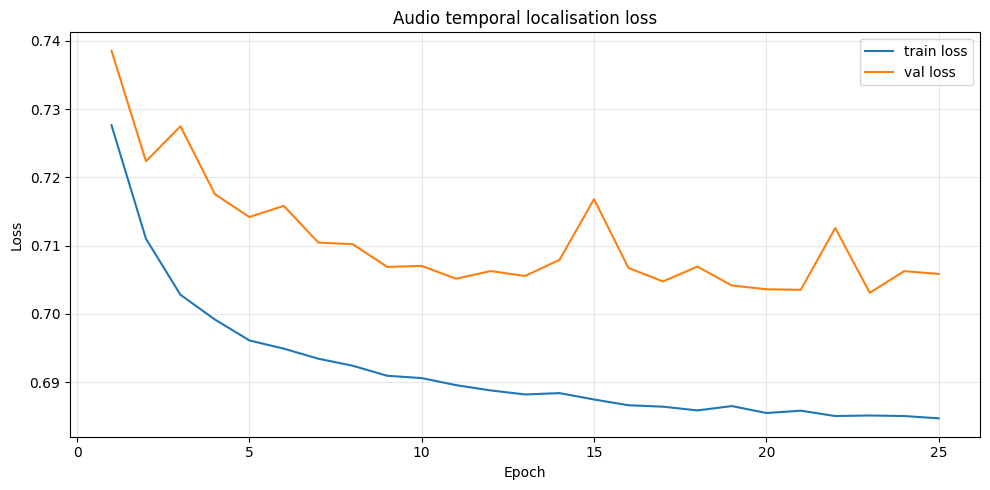

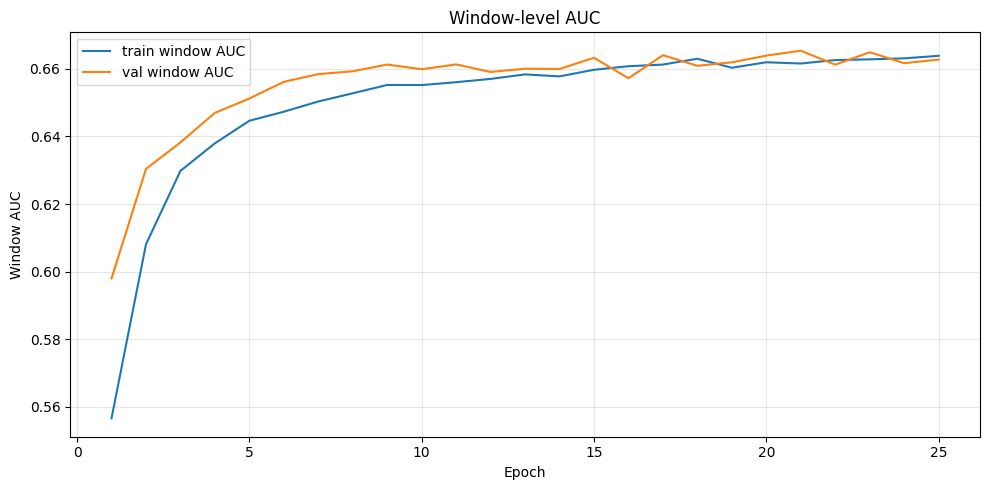

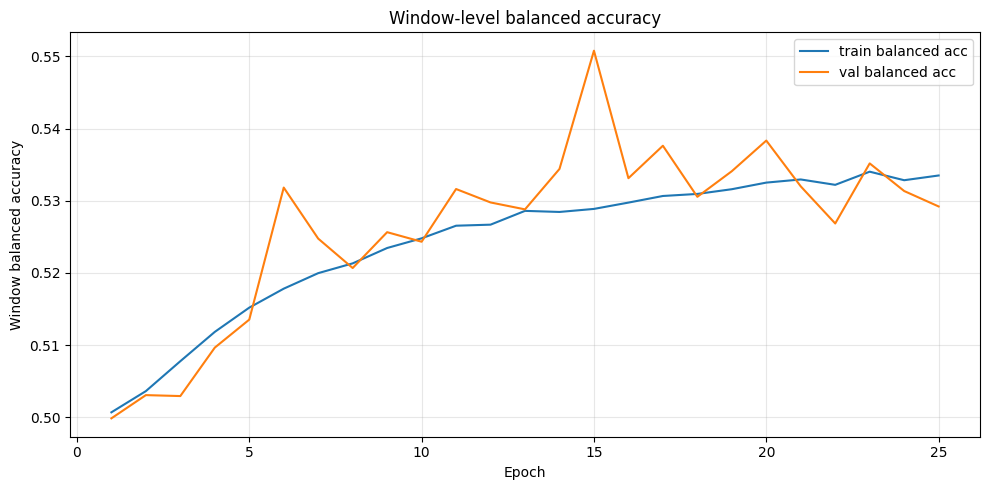

In [27]:
# training curves from the saved audio history csv

history_df = pd.read_csv(RESULTS_DIR / "audio_temporal_training_history.csv")
display(history_df.tail())

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Audio temporal localisation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "audio_temporal_loss.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_window_auc"], label="train window AUC")
plt.plot(history_df["epoch"], history_df["val_window_auc"], label="val window AUC")
plt.xlabel("Epoch")
plt.ylabel("Window AUC")
plt.title("Window-level AUC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "window_auc.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_window_balanced_accuracy"], label="train balanced acc")
plt.plot(history_df["epoch"], history_df["val_window_balanced_accuracy"], label="val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Window balanced accuracy")
plt.title("Window-level balanced accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "window_balanced_accuracy.png", dpi=200)
plt.show()

## test evaluation

load the best validation-auc checkpoint, then evaluate the held-out test windows.

after that the flat window predictions are grouped back into clips for max-pooling, sampled-window iou and condition checks.

In [28]:
# load the best checkpoint and get probabilities for every sampled test window

checkpoint_path = CHECKPOINT_DIR / "best_audio_temporal_head.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

audio_model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded:", checkpoint_path)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Val metrics:", checkpoint["val_metrics"])

test_window_metrics, test_y_true, test_y_prob, test_repeated_indices, test_repeated_video_labels, test_repeated_decode_ok = evaluate_audio_temporal_model(
    audio_model,
    test_shard_paths,
    criterion,
    device,
    batch_size=TEMPORAL_BATCH_SIZE,
    threshold=DEFAULT_THRESHOLD,
)

test_window_metrics_df = pd.DataFrame([{
    "threshold": DEFAULT_THRESHOLD,
    **test_window_metrics,
}])

test_window_metrics_path = RESULTS_DIR / "test_window_metrics.csv"
test_window_metrics_df.to_csv(test_window_metrics_path, index=False)

display(test_window_metrics_df)
print("Saved:", test_window_metrics_path)

Loaded: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/checkpoints/best_audio_temporal_head.pt
Checkpoint epoch: 21
Val metrics: {'loss': 0.7035330837567647, 'window_accuracy': 0.9753697916666667, 'window_balanced_accuracy': 0.5319956373709926, 'window_f1': 0.09092656670511341, 'window_precision': 0.12005076142131979, 'window_recall': 0.07317450495049505, 'window_auc': 0.665390366615356}


,threshold,loss,window_accuracy,window_balanced_accuracy,window_f1,window_precision,window_recall,window_auc
0,0.5,0.692122,0.975339,0.533423,0.092738,0.117876,0.076437,0.671117


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/test_window_metrics.csv


In [29]:
# save one row per sampled audio window and join the clip metadata back on

test_window_predictions_df = pd.DataFrame({
    "row_index": test_repeated_indices,
    "window_true": test_y_true,
    "window_prob": test_y_prob,
    "decode_ok": test_repeated_decode_ok,
})

test_window_predictions_df["window_pred"] = (test_window_predictions_df["window_prob"] >= DEFAULT_THRESHOLD).astype(int)
test_window_predictions_df["window_idx"] = test_window_predictions_df.groupby("row_index").cumcount()

test_meta = test_df.reset_index().rename(columns={"index": "row_index"})
meta_cols = [c for c in ["row_index", CONDITION_COL, "visual_fake", "audio_fake", "binary_label"] if c in test_meta.columns]

test_window_predictions_df = test_window_predictions_df.merge(
    test_meta[meta_cols],
    on="row_index",
    how="left",
)

window_pred_path = RESULTS_DIR / "test_window_predictions.csv"
test_window_predictions_df.to_csv(window_pred_path, index=False)

display(test_window_predictions_df.head())
print("Saved:", window_pred_path)

,row_index,window_true,window_prob,decode_ok,window_pred,window_idx,condition,visual_fake,audio_fake,binary_label
0,0,0,0.293920,1,0,0,real,0,0,0
1,0,0,0.289371,1,0,1,real,0,0,0
2,0,0,0.281593,1,0,2,real,0,0,0
3,0,0,0.285558,1,0,3,real,0,0,0
4,0,0,0.272773,1,0,4,real,0,0,0


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/test_window_predictions.csv


In [30]:
# group the 64 window predictions back into clips and calculate sampled-window iou

clip_rows = []

for row_index, group in test_window_predictions_df.groupby("row_index"):
    true_windows = group["window_true"].values.astype(int)
    probs = group["window_prob"].values

    pred_windows = (probs >= DEFAULT_THRESHOLD).astype(int)

    clip_true = int(true_windows.max() > 0)
    clip_prob_max = float(probs.max())
    clip_prob_mean = float(probs.mean())
    clip_pred = int(clip_prob_max >= DEFAULT_THRESHOLD)

    intersection = np.logical_and(true_windows == 1, pred_windows == 1).sum()
    union = np.logical_or(true_windows == 1, pred_windows == 1).sum()
    sampled_iou = float(intersection / union) if union > 0 else np.nan

    clip_rows.append({
        "row_index": int(row_index),
        "condition": group[CONDITION_COL].iloc[0],
        "visual_fake": int(group["visual_fake"].iloc[0]),
        "audio_fake": int(group["audio_fake"].iloc[0]),
        "binary_label": int(group["binary_label"].iloc[0]),
        "decode_ok": int(group["decode_ok"].iloc[0]),
        "clip_true_audio_fake_from_windows": clip_true,
        "clip_pred_audio_fake": clip_pred,
        "clip_prob_max": clip_prob_max,
        "clip_prob_mean": clip_prob_mean,
        "positive_true_windows": int(true_windows.sum()),
        "positive_pred_windows": int(pred_windows.sum()),
        "sampled_window_iou": sampled_iou,
    })

test_clip_predictions_df = pd.DataFrame(clip_rows)

clip_pred_path = RESULTS_DIR / "test_clip_predictions.csv"
test_clip_predictions_df.to_csv(clip_pred_path, index=False)

display(test_clip_predictions_df.head())
print("Saved:", clip_pred_path)

,row_index,condition,visual_fake,audio_fake,binary_label,decode_ok,clip_true_audio_fake_from_windows,clip_pred_audio_fake,clip_prob_max,clip_prob_mean,positive_true_windows,positive_pred_windows,sampled_window_iou
0,0,real,0,0,0,1,0,0,0.308035,0.215846,0,0,NaN
1,1,fake_video_fake_audio,1,1,1,1,1,0,0.354781,0.268322,2,0,0.0
2,2,real,0,0,0,1,0,0,0.342622,0.233024,0,0,NaN
3,3,real,0,0,0,1,0,0,0.365666,0.228823,0,0,NaN
4,4,real_video_fake_audio,0,1,1,1,1,0,0.463201,0.316005,2,0,0.0


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/test_clip_predictions.csv


In [31]:
# clip-level view using the maximum audio-window probability

clip_true = test_clip_predictions_df["clip_true_audio_fake_from_windows"].values.astype(int)
clip_prob = test_clip_predictions_df["clip_prob_max"].values
clip_pred = test_clip_predictions_df["clip_pred_audio_fake"].values.astype(int)

clip_metrics = {
    "threshold": DEFAULT_THRESHOLD,
    "clip_accuracy": accuracy_score(clip_true, clip_pred),
    "clip_balanced_accuracy": balanced_accuracy_score(clip_true, clip_pred),
    "clip_f1": f1_score(clip_true, clip_pred, zero_division=0),
    "clip_precision": precision_score(clip_true, clip_pred, zero_division=0),
    "clip_recall": recall_score(clip_true, clip_pred, zero_division=0),
    "clip_auc": safe_auc(clip_true, clip_prob),
}

clip_metrics_df = pd.DataFrame([clip_metrics])
clip_metrics_path = RESULTS_DIR / "test_clip_metrics.csv"
clip_metrics_df.to_csv(clip_metrics_path, index=False)

display(clip_metrics_df)
print("Saved:", clip_metrics_path)

,threshold,clip_accuracy,clip_balanced_accuracy,clip_f1,clip_precision,clip_recall,clip_auc
0,0.5,0.636333,0.531904,0.285527,0.414843,0.217673,0.572024


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/test_clip_metrics.csv


In [32]:
# localisation summary on audio-fake clips only

positive_clips = test_clip_predictions_df[
    test_clip_predictions_df["clip_true_audio_fake_from_windows"] == 1
].copy()

localisation_metrics = {
    "n_positive_audio_fake_clips": len(positive_clips),
    "mean_sampled_window_iou_positive_clips": float(positive_clips["sampled_window_iou"].mean()) if len(positive_clips) else np.nan,
    "median_sampled_window_iou_positive_clips": float(positive_clips["sampled_window_iou"].median()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_1": float((positive_clips["sampled_window_iou"] >= 0.1).mean()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_3": float((positive_clips["sampled_window_iou"] >= 0.3).mean()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_5": float((positive_clips["sampled_window_iou"] >= 0.5).mean()) if len(positive_clips) else np.nan,
}

localisation_metrics_df = pd.DataFrame([localisation_metrics])
localisation_metrics_path = RESULTS_DIR / "test_localisation_metrics.csv"
localisation_metrics_df.to_csv(localisation_metrics_path, index=False)

display(localisation_metrics_df)
print("Saved:", localisation_metrics_path)

,n_positive_audio_fake_clips,mean_sampled_window_iou_positive_clips,median_sampled_window_iou_positive_clips,recall_iou_ge_0_1,recall_iou_ge_0_3,recall_iou_ge_0_5
0,2003,0.033225,0.0,0.095357,0.052421,0.023964


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/test_localisation_metrics.csv


In [33]:
# condition breakdown - fake_video_real_audio is the useful audio shortcut check

condition_rows = []

for condition, window_group in test_window_predictions_df.groupby(CONDITION_COL):
    y_true = window_group["window_true"].values.astype(int)
    y_prob = window_group["window_prob"].values
    y_pred = window_group["window_pred"].values.astype(int)

    clip_group = test_clip_predictions_df[test_clip_predictions_df["condition"] == condition]

    condition_rows.append({
        "condition": condition,
        "n_videos": int(len(clip_group)),
        "n_windows": int(len(window_group)),
        "true_positive_window_rate": float(y_true.mean()),
        "predicted_positive_window_rate": float(y_pred.mean()),
        "mean_audio_fake_probability": float(y_prob.mean()),
        "window_accuracy": accuracy_score(y_true, y_pred),
        "window_balanced_accuracy": balanced_accuracy_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "window_f1": f1_score(y_true, y_pred, zero_division=0),
        "window_precision": precision_score(y_true, y_pred, zero_division=0),
        "window_recall": recall_score(y_true, y_pred, zero_division=0),
        "window_auc": safe_auc(y_true, y_prob),
        "clip_predicted_audio_fake_rate": float(clip_group["clip_pred_audio_fake"].mean()) if len(clip_group) else np.nan,
        "clip_mean_max_probability": float(clip_group["clip_prob_max"].mean()) if len(clip_group) else np.nan,
        "mean_sampled_window_iou": float(clip_group["sampled_window_iou"].mean()) if len(clip_group) else np.nan,
        "decode_ok_rate": float(clip_group["decode_ok"].mean()) if len(clip_group) else np.nan,
    })

condition_metrics_df = pd.DataFrame(condition_rows).sort_values("condition")

condition_metrics_path = RESULTS_DIR / "condition_audio_temporal_metrics.csv"
condition_metrics_df.to_csv(condition_metrics_path, index=False)

display(condition_metrics_df)
print("Saved:", condition_metrics_path)

,condition,n_videos,n_windows,true_positive_window_rate,predicted_positive_window_rate,mean_audio_fake_probability,window_accuracy,window_balanced_accuracy,window_f1,window_precision,window_recall,window_auc,clip_predicted_audio_fake_rate,clip_mean_max_probability,mean_sampled_window_iou,decode_ok_rate
0,fake_video_fake_audio,1001,64064,0.048358,0.015485,0.235832,0.943806,0.533415,0.119804,0.246976,0.079083,0.667276,0.220779,0.431227,0.034656,1.0
1,fake_video_real_audio,972,62208,0.000000,0.009436,0.224976,0.990564,NaN,0.000000,0.000000,0.000000,NaN,0.165638,0.404341,0.000000,1.0
2,real,3000,192000,0.000000,0.008234,0.225384,0.991766,NaN,0.000000,0.000000,0.000000,NaN,0.151000,0.399633,0.000000,1.0
3,real_video_fake_audio,1027,65728,0.049203,0.014393,0.233492,0.943677,0.531295,0.114354,0.252643,0.073902,0.653078,0.210321,0.428103,0.031801,1.0


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/condition_audio_temporal_metrics.csv


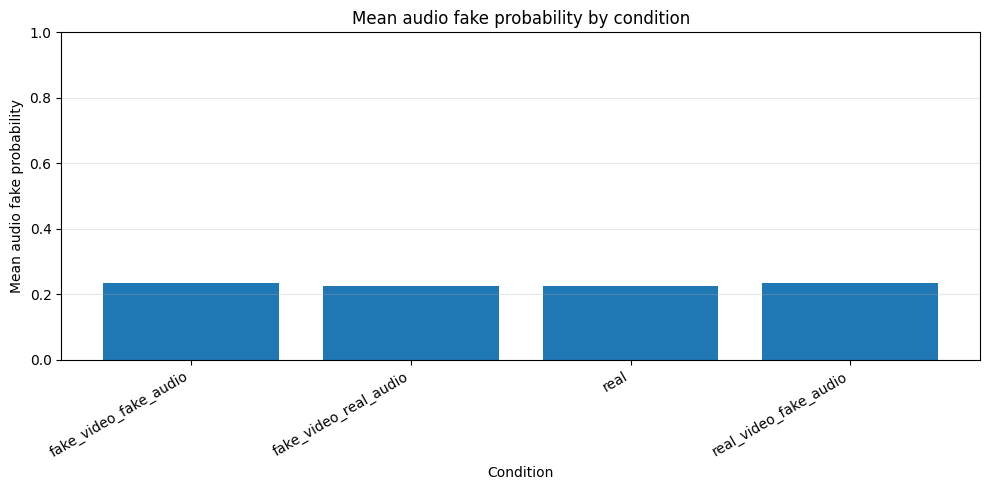

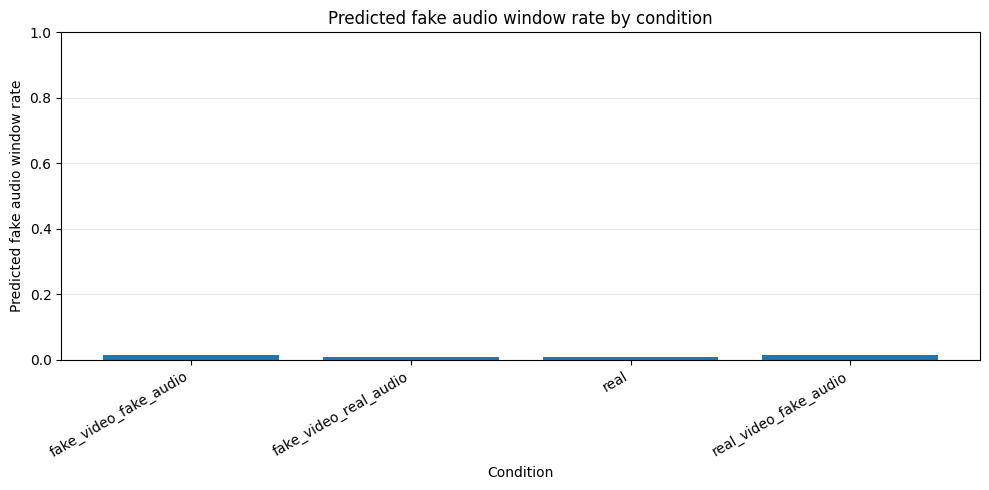

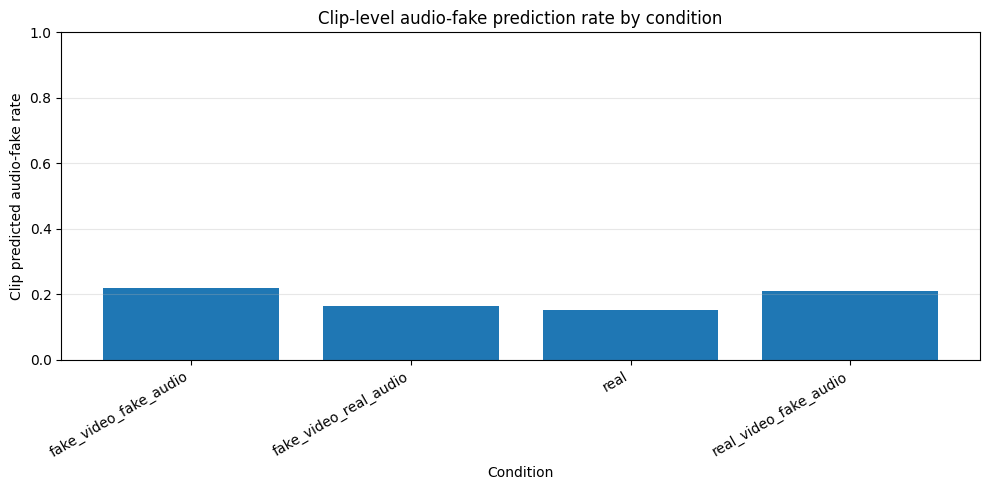

In [34]:
# a few condition plots from the saved test predictions

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["mean_audio_fake_probability"])
plt.xlabel("Condition")
plt.ylabel("Mean audio fake probability")
plt.title("Mean audio fake probability by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_mean_audio_fake_probability.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["predicted_positive_window_rate"])
plt.xlabel("Condition")
plt.ylabel("Predicted fake audio window rate")
plt.title("Predicted fake audio window rate by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_predicted_positive_window_rate.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["clip_predicted_audio_fake_rate"])
plt.xlabel("Condition")
plt.ylabel("Clip predicted audio-fake rate")
plt.title("Clip-level audio-fake prediction rate by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_clip_audio_fake_rate.png", dpi=200)
plt.show()

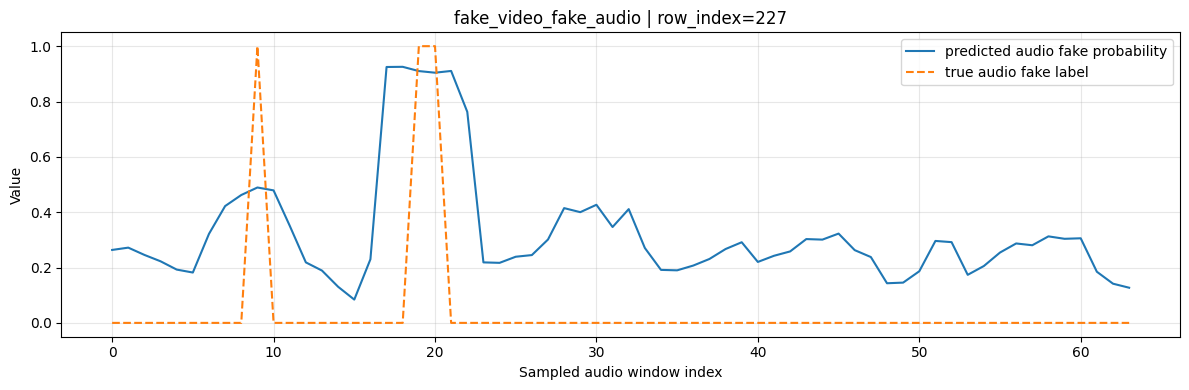

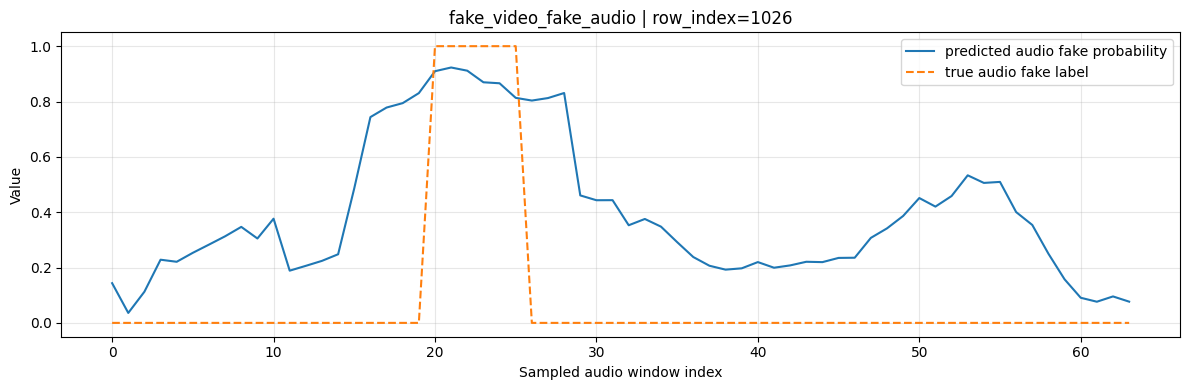

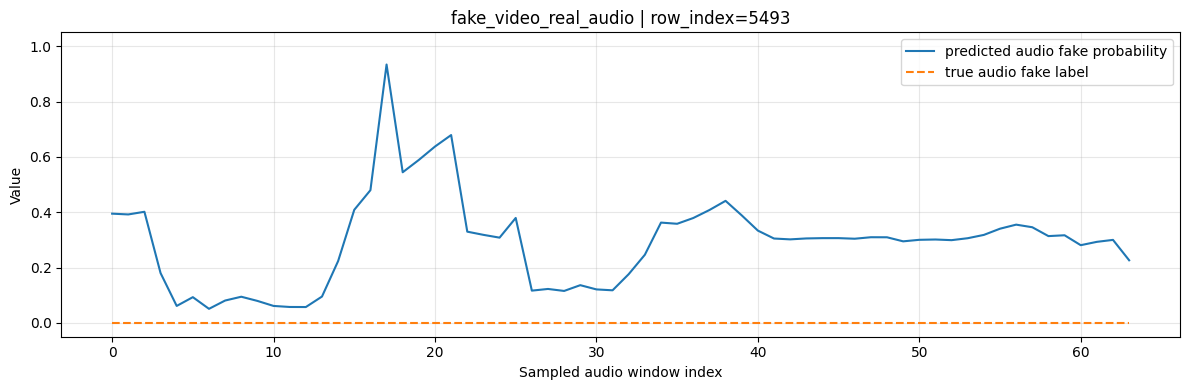

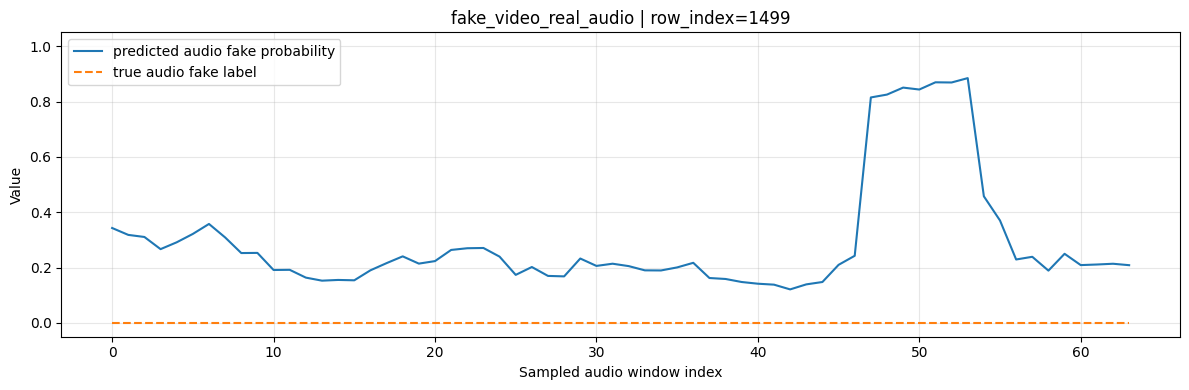

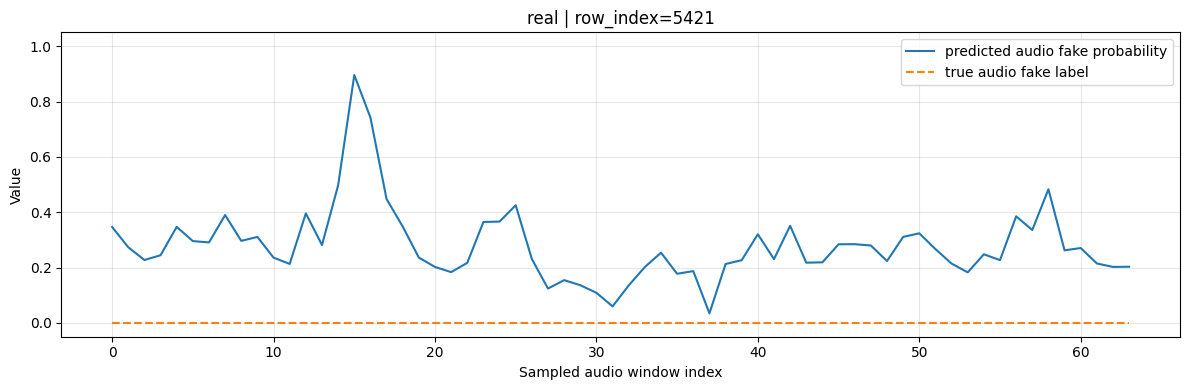

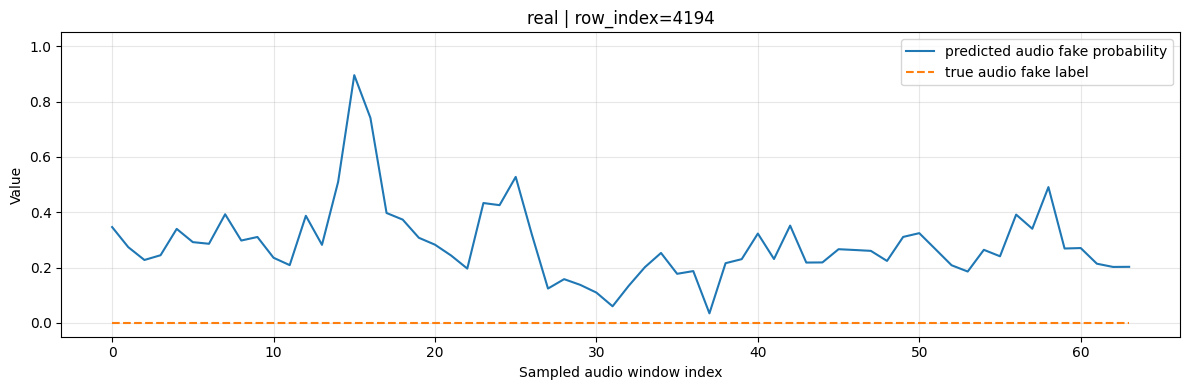

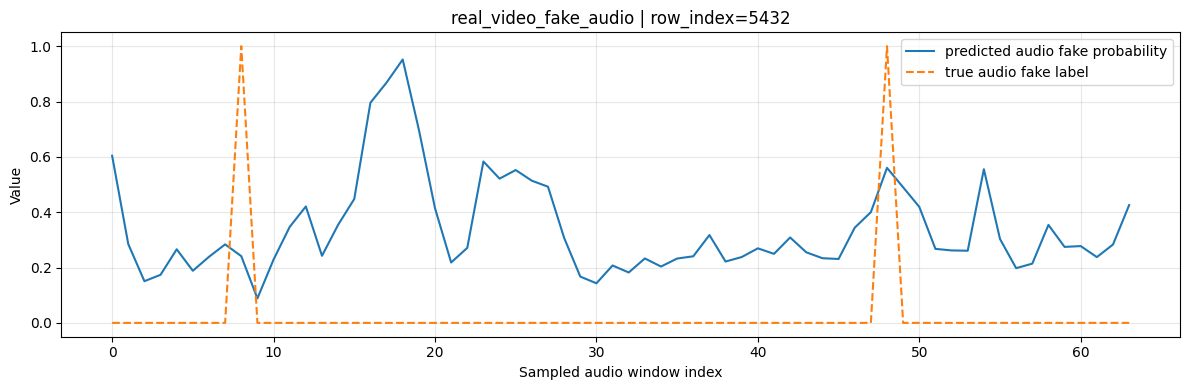

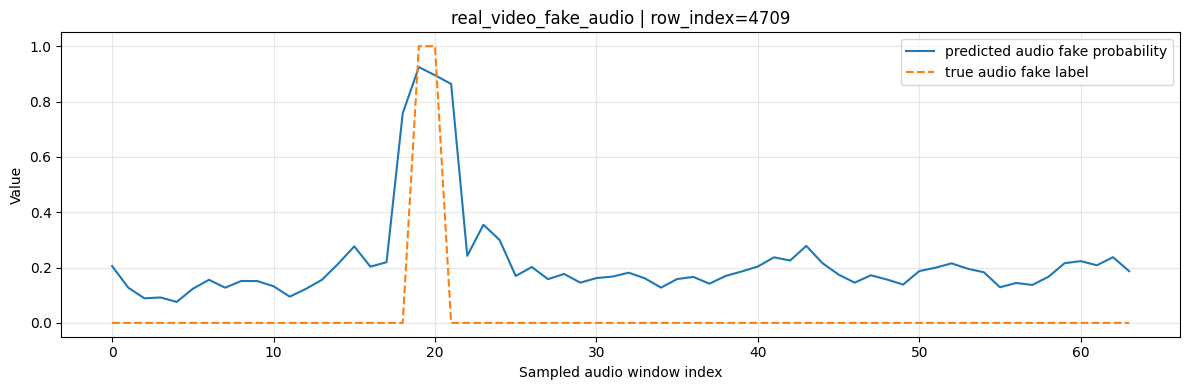

In [35]:
# show a couple of high-scoring temporal examples from each condition

for cond in sorted(test_window_predictions_df[CONDITION_COL].dropna().unique()):
    plot_audio_temporal_examples(test_window_predictions_df, test_clip_predictions_df, cond, PLOTS_DIR, n_examples=2)

## validation threshold check

0.5 is the default window threshold. i also search validation thresholds for the best window balanced accuracy, then apply that selected threshold once to the already-produced test probabilities.

In [36]:
# search validation thresholds from 0.05 to 0.95 using window balanced accuracy

val_window_metrics_default, val_y_true, val_y_prob, val_repeated_indices, val_repeated_video_labels, val_repeated_decode_ok = evaluate_audio_temporal_model(
    audio_model,
    val_shard_paths,
    criterion,
    device,
    batch_size=TEMPORAL_BATCH_SIZE,
    threshold=DEFAULT_THRESHOLD,
)

threshold_rows = []

for t in np.linspace(0.05, 0.95, 181):
    pred = (val_y_prob >= t).astype(int)

    threshold_rows.append({
        "threshold": float(t),
        "window_accuracy": accuracy_score(val_y_true, pred),
        "window_balanced_accuracy": balanced_accuracy_score(val_y_true, pred),
        "window_f1": f1_score(val_y_true, pred, zero_division=0),
        "window_precision": precision_score(val_y_true, pred, zero_division=0),
        "window_recall": recall_score(val_y_true, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values("window_balanced_accuracy", ascending=False).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

threshold_path = RESULTS_DIR / "validation_threshold_search.csv"
threshold_df.to_csv(threshold_path, index=False)

display(best_threshold_row)
print("Best validation threshold:", best_threshold)
print("Saved:", threshold_path)

threshold                   0.250000
window_accuracy             0.633154
window_balanced_accuracy    0.618427
window_f1                   0.052453
window_precision            0.027419
window_recall               0.603187
Name: 40, dtype: float64

Best validation threshold: 0.24999999999999994
Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/validation_threshold_search.csv


In [37]:
# apply the validation-selected threshold to the saved test probabilities

tuned_pred = (test_y_prob >= best_threshold).astype(int)

tuned_test_window_metrics = {
    "threshold": best_threshold,
    "window_accuracy": accuracy_score(test_y_true, tuned_pred),
    "window_balanced_accuracy": balanced_accuracy_score(test_y_true, tuned_pred),
    "window_f1": f1_score(test_y_true, tuned_pred, zero_division=0),
    "window_precision": precision_score(test_y_true, tuned_pred, zero_division=0),
    "window_recall": recall_score(test_y_true, tuned_pred, zero_division=0),
    "window_auc": safe_auc(test_y_true, test_y_prob),
}

tuned_test_window_metrics_df = pd.DataFrame([tuned_test_window_metrics])
tuned_metrics_path = RESULTS_DIR / "test_window_metrics_threshold_tuned.csv"
tuned_test_window_metrics_df.to_csv(tuned_metrics_path, index=False)

display(tuned_test_window_metrics_df)
print("Saved:", tuned_metrics_path)

,threshold,window_accuracy,window_balanced_accuracy,window_f1,window_precision,window_recall,window_auc
0,0.25,0.629591,0.620152,0.051545,0.026908,0.610392,0.671117


Saved: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k/results/test_window_metrics_threshold_tuned.csv


In [ ]:
# save a short text summary beside the experiment outputs

run_notes = "# " + RUN_NAME + " run notes\n\n"
run_notes += "## Purpose\n\nAudio temporal localisation on the balanced 40k group-disjoint split.\n\n"
run_notes += "## Key methodological point\n\n"
run_notes += "This is not generic binary fake/real detection. The target is window-level audio manipulation derived from condition and `" + AUDIO_SEGMENT_COL + "`.\n\n"
run_notes += "## Condition logic\n\n"
run_notes += "- real: all audio window labels should be 0\n"
run_notes += "- fake_video_real_audio: all audio window labels should be 0\n"
run_notes += "- real_video_fake_audio: audio fake windows from segment labels\n"
run_notes += "- fake_video_fake_audio: audio fake windows from segment labels\n\n"
run_notes += "## Shortcut analysis\n\n"
run_notes += "The most important shortcut check is predicted fake audio rate for `fake_video_real_audio`.\n\n"
run_notes += "## Feature type\n\n"
run_notes += "The baseline uses 64 uniformly sampled log-STFT temporal windows per clip. Each window is represented by mean and standard deviation of log magnitude STFT bins.\n\n"
run_notes += "## Config\n\n```json\n"
run_notes += json.dumps(EXPERIMENT_CONFIG, indent=2)
run_notes += "\n```\n\n"
run_notes += "## Split source\n\n" + SPLIT_SOURCE_EXPERIMENT + "\n\n"
run_notes += "## Metadata path used\n\n" + (str(metadata_path) if metadata_path is not None else "None") + "\n\n"
run_notes += "## Snapshot warning\n\n"
run_notes += "The final notebook snapshot only copies:\n" + str(NOTEBOOK_PATH) + "\n"
run_notes += "The notebook had to be saved before the snapshot helper copied it.\n"

run_notes_path = RUN_DIRS["run"] / "run_notes.md"
run_notes_path.write_text(run_notes, encoding="utf-8")

print("Saved:", run_notes_path)

In [ ]:
# old helper used to copy the saved notebook into the run folder

def save_final_notebook_snapshot(notebook_path, run_dirs):
    """copy the saved notebook file into the experiment snapshot folder."""
    notebook_path = Path(notebook_path)
    snapshot_dir = Path(run_dirs["notebook"])
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    if not notebook_path.exists():
        raise FileNotFoundError(
            f"Notebook path does not exist: {notebook_path}\n"
            f"Save this notebook as {notebook_path} first, then rerun this cell."
        )

    if notebook_path.name != NOTEBOOK_FILENAME:
        raise ValueError(
            f"Refusing to snapshot unexpected notebook name: {notebook_path.name}\n"
            f"Expected: {NOTEBOOK_FILENAME}"
        )

    size_kb = notebook_path.stat().st_size / 1024
    if size_kb < 10:
        raise ValueError(f"Notebook file looks too small ({size_kb:.1f} KB). Refusing snapshot.")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    snapshot_path = snapshot_dir / f"final_snapshot_{timestamp}.ipynb"

    shutil.copy2(notebook_path, snapshot_path)

    snapshot_note = snapshot_dir / "snapshot_source.txt"
    snapshot_note.write_text(
        f"Snapshot created at: {datetime.now().isoformat(timespec='seconds')}\n"
        f"Source notebook: {notebook_path}\n"
        f"Snapshot path: {snapshot_path}\n"
        f"Source size KB: {size_kb:.1f}\n",
        encoding="utf-8",
    )

    print("Final notebook snapshot saved:", snapshot_path)
    print("Snapshot source note:", snapshot_note)

    return snapshot_path


# this copied whatever version of the notebook had actually been saved to disk
snapshot_path = save_final_notebook_snapshot(NOTEBOOK_PATH, RUN_DIRS)

In [ ]:
# make a csv index of the files produced by the run

def create_experiment_index(run_dirs):
    """list the run files, sizes and modification times in one csv."""
    run_dir = Path(run_dirs["run"])
    rows = []

    for section, folder in run_dirs.items():
        folder = Path(folder)
        if not folder.exists() or not folder.is_dir():
            continue

        for file in folder.rglob("*"):
            if not file.is_file():
                continue

            rows.append({
                "section": section,
                "filename": file.name,
                "path": str(file),
                "size_mb": file.stat().st_size / 1024**2,
                "modified_at": datetime.fromtimestamp(file.stat().st_mtime).isoformat(timespec="seconds"),
            })

    index_df = pd.DataFrame(rows).sort_values(["section", "path"])
    index_path = run_dir / "archive_index.csv"
    index_df.to_csv(index_path, index=False)

    print("Saved:", index_path)
    display(index_df)

    return index_df


experiment_index_df = create_experiment_index(RUN_DIRS)

In [ ]:
# build a smaller export zip with short internal paths

def safe_filename(name, max_len=60):
    """clean/shorten a filename before using it inside the export zip."""
    p = Path(name)
    stem = p.stem
    suffix = p.suffix

    safe = "".join(c if c.isalnum() or c in "._-" else "_" for c in stem).strip("_-.")

    if not safe:
        safe = "file"

    if len(safe) > max_len:
        h = hashlib.md5(safe.encode("utf-8")).hexdigest()[:8]
        safe = safe[:max_len - 9] + "_" + h

    return safe + suffix


def zip_experiment_shortpaths(
    run_dir,
    exports_dir,
    short_name,
    include_checkpoints=True,
    include_features=False,
    max_filename_len=60,
):
    """zip the run outputs while leaving out the large feature cache by default."""
    run_dir = Path(run_dir)
    exports_dir = Path(exports_dir)
    exports_dir.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_path = exports_dir / f"{short_name}_{timestamp}.zip"

    mapping_rows = []

    folder_replacements = {
        "checkpoints": "ckpt",
        "manifests": "man",
        "results": "res",
        "plots": "plt",
        "notebook": "nb",
        "features": "feat",
    }

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in run_dir.rglob("*"):
            if not file.is_file():
                continue

            rel = file.relative_to(run_dir)

            if ".ipynb_checkpoints" in rel.parts:
                continue

            if not include_checkpoints and file.suffix in [".pt", ".pth", ".ckpt"]:
                continue

            if not include_features and "features" in rel.parts:
                continue

            parts = []
            for part in rel.parts[:-1]:
                parts.append(folder_replacements.get(part, safe_filename(part, max_len=30)))

            parts.append(safe_filename(rel.parts[-1], max_len=max_filename_len))

            arcname = Path(short_name, *parts)

            zipf.write(file, arcname=str(arcname))

            mapping_rows.append({
                "original_path": str(file),
                "archive_path": str(arcname),
            })

        mapping_df = pd.DataFrame(mapping_rows)
        zipf.writestr(
            f"{short_name}/archive_path_mapping.csv",
            mapping_df.to_csv(index=False),
        )

    print("Created:", zip_path)
    print(f"Size: {zip_path.stat().st_size / 1024**2:.2f} MB")
    print("Features included:", include_features)

    return zip_path


zip_path = zip_experiment_shortpaths(
    run_dir=RUN_DIRS["run"],
    exports_dir=EXPORTS_DIR,
    short_name=RUN_NAME,
    include_checkpoints=True,
    include_features=False,
)

display(FileLink(str(zip_path)))

## result reminders

things i need to remember from exp005:

- window auc is the main ranking metric for the sampled audio windows
- the sampled-window iou is much weaker, so ranking fake windows and getting clean temporal overlap are different things
- clip scores here come from max-pooling the 64 audio-window probabilities
- `fake_video_real_audio` should be audio-real, so activation there is the shortcut/failure check
- 402 features = 201 stft frequency bins x (mean + std)
- the head is only layernorm + linear, with no explicit temporal-context model
- the decode preflight matters because the first attempt failed by producing zero audio features
- classification threshold can be selected on validation, while the localisation view still uses the fixed 0.5 window threshold where reported